In [7]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
import os
import sys
from pathlib import Path
import yaml
import zipfile

%load_ext autoreload
%autoreload 2
    
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))             

with open(PROJECT_ROOT / "config.yaml", encoding="utf-8") as f:
    config = yaml.safe_load(f)
import functions as fn

#Data raw folder path:
raw_folder = r"C:\Users\ziden\Desktop\Trainings\RNCP-Project\data\raw"
#Data clean folder path:
clean_folder = r"C:\Users\ziden\Desktop\Trainings\RNCP-Project\data\clean"

In [9]:
qos_raw = pd.read_csv(os.path.join(raw_folder, "2025_QoS_Metropole_data_habitations.csv"), sep = ";", encoding="latin1" )
qos_raw.head()

C:\Users\ziden\AppData\Local\Temp\ipykernel_27584\2848646370.py:1: DtypeWarning: Columns (0: insee_com) have mixed types. Specify dtype option on import or set low_memory=False.
  qos_raw = pd.read_csv(os.path.join(raw_folder, "2025_QoS_Metropole_data_habitations.csv"), sep = ";", encoding="latin1" )


,acess_duration,average_mos_couple,axis,axis_name,axis_precision,band_serving,band_start,bitrate_dl,bitrate_ul,call_direction,...,upload_ok,url,video_freez_duration,video_initialisation_duration,video_viewing_duration,zone,zone_name,zone_precision,Unnamed: 101,Result
0,"2,64",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,https://www.assurance-maladie.ameli.fr/qui-som...,NaN,NaN,NaN,Zones intermediaires,Dax,NaN,NaN,Success
1,"2,45",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,https://www.assurance-maladie.ameli.fr/qui-som...,NaN,NaN,NaN,Zones intermediaires,Dax,NaN,NaN,Success
2,"2,48",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,https://www.assurance-maladie.ameli.fr/qui-som...,NaN,NaN,NaN,Zones intermediaires,Dax,NaN,NaN,Success
3,"2,25",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,https://www.assurance-maladie.ameli.fr/qui-som...,NaN,NaN,NaN,Zones intermediaires,Dax,NaN,NaN,Success
4,"3,41",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,https://www.doctolib.fr/,NaN,NaN,NaN,Zones intermediaires,Dax,NaN,NaN,Success


In [11]:
qos_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 354282 entries, 0 to 354281
Columns: 103 entries, acess_duration to Result
dtypes: float64(87), object(1), str(15)
memory usage: 278.4+ MB


In [15]:
qos_clean = pd.read_csv(os.path.join(clean_folder, "5G_qos_clean.csv"), sep = ",", encoding="latin1" )
qos_clean.head()

C:\Users\ziden\AppData\Local\Temp\ipykernel_27584\3937796946.py:1: DtypeWarning: Columns (0: insee_com) have mixed types. Specify dtype option on import or set low_memory=False.
  qos_clean = pd.read_csv(os.path.join(clean_folder, "5G_qos_clean.csv"), sep = ",", encoding="latin1" )


,measure_id,acess_duration,bitrate_dl,bitrate_ul,date_start,hour_start,insee_com,latitude_start,loaded_in_less_10_secondes,loaded_in_less_5_secondes,...,protocole,situation,techno_start,terminal,url,zone,zone_name,Result,operator_id,protocol_id
0,1,2.64,NaN,NaN,2025-06-23,10:29:02,40088,43.7196,1.0,1.0,...,WEB,Incar,5G,SM-F731B,https://www.assurance-maladie.ameli.fr/qui-som...,Zones intermediaires,Dax,Success,2,1
1,2,2.45,NaN,NaN,2025-06-23,10:29:02,40088,43.7196,1.0,1.0,...,WEB,Incar,5G,SM-F731B,https://www.assurance-maladie.ameli.fr/qui-som...,Zones intermediaires,Dax,Success,4,1
2,3,2.48,NaN,NaN,2025-06-23,10:29:02,40088,43.7196,1.0,1.0,...,WEB,Incar,5G,SM-F731B,https://www.assurance-maladie.ameli.fr/qui-som...,Zones intermediaires,Dax,Success,1,1
3,4,2.25,NaN,NaN,2025-06-23,10:29:02,40088,43.7196,1.0,1.0,...,WEB,Incar,5G,SM-F731B,https://www.assurance-maladie.ameli.fr/qui-som...,Zones intermediaires,Dax,Success,3,1
4,5,3.41,NaN,NaN,2025-06-23,10:29:15,40088,43.7196,1.0,1.0,...,WEB,Incar,5G,SM-F731B,https://www.doctolib.fr/,Zones intermediaires,Dax,Success,3,1


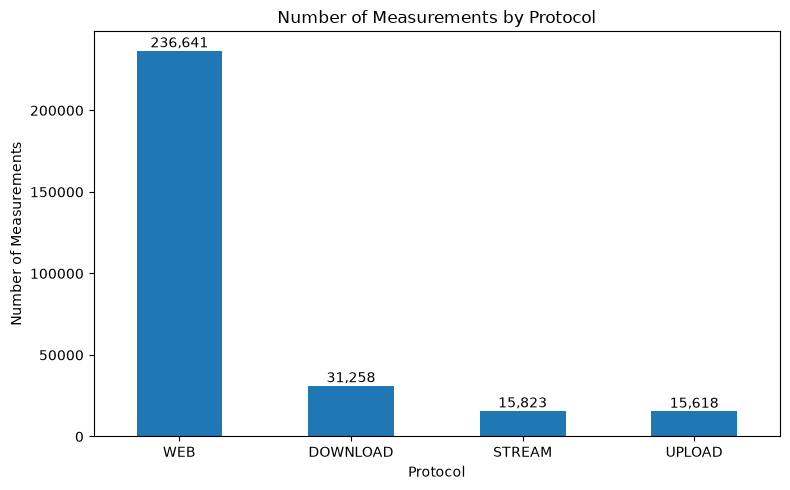

In [19]:
import matplotlib.pyplot as plt

protocol_counts = qos_clean["protocole"].value_counts()

ax = protocol_counts.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Number of Measurements by Protocol")
plt.xlabel("Protocol")
plt.ylabel("Number of Measurements")
plt.xticks(rotation=0)

# Show values
for i, value in enumerate(protocol_counts):
    ax.text(i, value, f"{value:,}", ha="center", va="bottom")

plt.tight_layout()
plt.show()